Invalid Data Points:
Empty DataFrame
Columns: [Date, Ppt, SWC_5, SWC_10, SWC_20, SWC_50, T_5, T_10, T_20, T_50, Flag]
Index: []

Missing Data:
SWC_5     4
SWC_10    5
SWC_20    5
SWC_50    6
T_5       3
T_10      3
T_20      3
T_50      3
dtype: int64


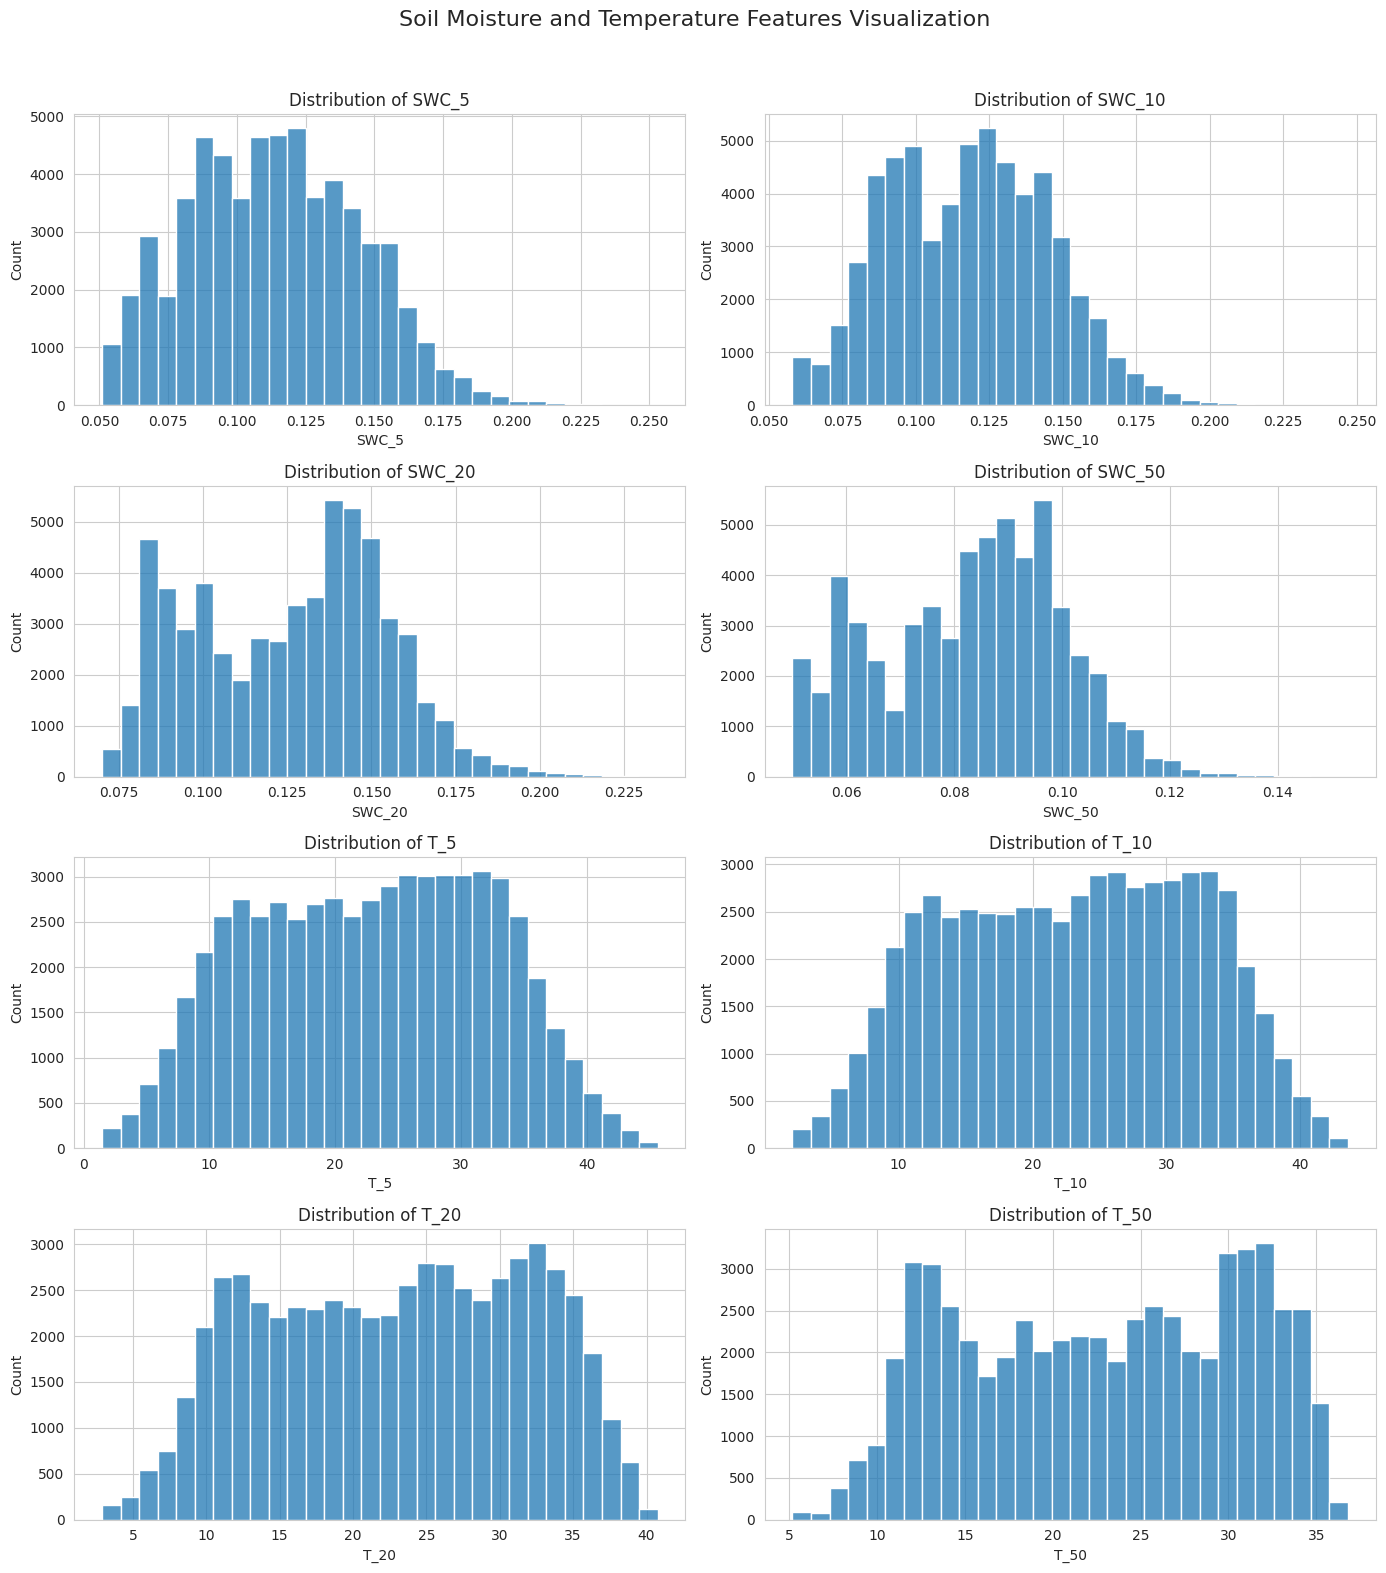

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your SM dataset without limiting rows
df = pd.read_csv('SM_6.dat')

# Clean column names
df.columns = df.columns.str.strip()

# Convert relevant columns to numeric, coercing errors to NaN
df[['SWC_5', 'SWC_10', 'SWC_20', 'SWC_50', 'T_5', 'T_10', 'T_20', 'T_50']] = df[['SWC_5', 'SWC_10', 'SWC_20', 'SWC_50', 'T_5', 'T_10', 'T_20', 'T_50']].apply(pd.to_numeric, errors='coerce')

# Set the style for the plots
sns.set_style("whitegrid")

# Optimized function to validate data based on criteria for soil moisture and temperature
def validate_data(df):
    mask = (
        # SWC should be between 0 and 1 (representing a range of soil moisture content)
        ((df['SWC_5'] < 0) | (df['SWC_5'] > 0.6)) |
        ((df['SWC_10'] < 0) | (df['SWC_10'] > 0.6)) |
        ((df['SWC_20'] < 0) | (df['SWC_20'] > 0.6)) |
        ((df['SWC_50'] < 0) | (df['SWC_50'] > 0.6)) |
        # Temperature values should be within a reasonable range for soil (e.g., -40 to 80°C)
        ((df['T_5'] < -40) | (df['T_5'] > 80)) |
        ((df['T_10'] < -40) | (df['T_10'] > 80)) |
        ((df['T_20'] < -40) | (df['T_20'] > 80)) |
        ((df['T_50'] < -40) | (df['T_50'] > 80))
    )
    return df[mask]

# Run validation on the dataset
invalid_data = validate_data(df)
print("Invalid Data Points:")
print(invalid_data)

# Display missing data summary
missing_data = df.isnull().sum()
print("\nMissing Data:")
print(missing_data[missing_data > 0])

# Create subplots
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
fig.suptitle('Soil Moisture and Temperature Features Visualization', fontsize=16)

# Define features and axes mapping
features = ['SWC_5', 'SWC_10', 'SWC_20', 'SWC_50', 'T_5', 'T_10', 'T_20', 'T_50']
axes = axes.flatten()

# Plot each feature
for i, feature in enumerate(features):
    if feature in df.columns:
        sns.histplot(df[feature].dropna(), bins=30, kde=False, ax=axes[i])  # KDE disabled for speed
        axes[i].set_title(f'Distribution of {feature}')
    else:
        axes[i].text(0.5, 0.5, f'{feature} not found', horizontalalignment='center', verticalalignment='center', transform=axes[i].transAxes)
        axes[i].set_xticks([])
        axes[i].set_yticks([])

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
